# ARI5102 (Data Analysis Techniques) Assignment

UOM Assignment for the ARI5102 (Data Analysis Techniques) study-unit.

## Imports

Import any code packages required in this notebook

In [1]:
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    mean_absolute_error
)
from sklearn import tree
from scipy.stats import spearmanr

from IPython.display import display

## Task 1

### Code

**Very simple Exploratory Data Analysis (EDA)**

We print very basic information on the DataFrame.

In [2]:
dataset_path = "data/dataset.csv"
pdf = pd.read_csv(dataset_path)

print(f"Dataset shape: {pdf.shape}")
print(f"\nColumn names: {pdf.columns.tolist()}")

print("\nDataset Info:")
display(pdf.info())

print("\nDataset Described:")
display(pdf.describe())

Dataset shape: (2500, 82)

Column names: ['q1_1', 'q2_1', 'q3_1', 'q3_2', 'q3_3', 'q3_4', 'q3_5', 'q3_6', 'q3_7', 'q3_8', 'q3_9', 'q3_10', 'q4_1', 'q4_2', 'q4_3', 'q4_4', 'q4_5', 'q4_6', 'q4_7', 'q4_8', 'q4_9', 'q4_10', 'q5_1', 'q5_2', 'q5_3', 'q5_4', 'q5_5', 'q5_6', 'q5_7', 'q5_8', 'q5_9', 'q5_10', 'q6_1', 'q6_2', 'q6_3', 'q6_4', 'q6_5', 'q6_6', 'q6_7', 'q6_8', 'q6_9', 'q6_10', 'q7_1', 'q7_2', 'q7_3', 'q7_4', 'q7_5', 'q7_6', 'q7_7', 'q7_8', 'q7_9', 'q7_10', 'q8_1', 'q8_2', 'q8_3', 'q8_4', 'q8_5', 'q8_6', 'q8_7', 'q8_8', 'q8_9', 'q8_10', 'q9_1', 'q9_2', 'q9_3', 'q9_4', 'q9_5', 'q9_6', 'q9_7', 'q9_8', 'q9_9', 'q9_10', 'q10_1', 'q10_2', 'q10_3', 'q10_4', 'q10_5', 'q10_6', 'q10_7', 'q10_8', 'q10_9', 'q10_10']

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 82 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   q1_1    2500 non-null   float64
 1   q2_1    2500 non-null   float64
 2   q3_1    2500 non-nul

None


Dataset Described:


,q1_1,q2_1,q3_1,q3_2,q3_3,q3_4,q3_5,q3_6,q3_7,q3_8,...,q10_1,q10_2,q10_3,q10_4,q10_5,q10_6,q10_7,q10_8,q10_9,q10_10
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,...,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.00000
mean,0.647200,0.454000,0.145600,0.048000,0.109200,0.074400,0.08320,0.109200,0.153200,0.068000,...,0.237200,0.177600,0.289600,0.233600,0.487600,0.261600,0.42440,0.196000,0.468000,0.19960
std,0.477937,0.497979,0.352775,0.213809,0.311952,0.262473,0.27624,0.311952,0.360252,0.251796,...,0.425451,0.382252,0.453667,0.423205,0.499946,0.439594,0.49435,0.397048,0.499075,0.39978
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.00000,0.000000,1.000000,0.00000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000


**Further analysis**

We analyse every question to determine the type of question it is and how many people answered.

In [3]:
def analyse_questions(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    n_respondents = len(df)

    # group columns by question prefix
    question_groups: dict[str, list[str]] = defaultdict(list)
    for col in columns:
        prefix = "_".join(col.split("_")[:-1]) # 'q3_1' results in 'q3'
        question_groups[prefix].append(col)

    records = []
    for question, cols in question_groups.items():
        question_df = df[cols]
        row_sums = question_df.sum(axis=1, skipna=True)
        is_multiple = (row_sums > 1).any()

        # a respondent skipped the question if ALL their values are NaN
        skipped_mask = question_df.isna().all(axis=1)
        n_missing = int(skipped_mask.sum())
        n_answered = n_respondents - n_missing
        pct_answered = 100 * n_answered / n_respondents

        records.append({
            "question"      : question,
            "possible_answers": len(cols),
            "selection_type": "multiple" if is_multiple else "single",
            "answered_by_all": n_missing == 0,
            "n_answered"    : n_answered,
            "n_missing"     : n_missing,
            "pct_answered"  : round(pct_answered, 1),
        })

    result = (
        pd.DataFrame(records)
        .set_index("question")
        .sort_index()
    )
    return result

summary = analyse_questions(pdf, pdf.columns.tolist())
display(summary)

,possible_answers,selection_type,answered_by_all,n_answered,n_missing,pct_answered
question,,,,,,
q1,1,single,True,2500,0,100.0
q10,10,multiple,True,2500,0,100.0
q2,1,single,True,2500,0,100.0
q3,10,single,True,2500,0,100.0
q4,10,single,True,2500,0,100.0
q5,10,single,True,2500,0,100.0
q6,10,multiple,False,1618,882,64.7
q7,10,multiple,True,2500,0,100.0
q8,10,multiple,False,1135,1365,45.4


### Answers

#### 1.1

The survey is made up of 10 different questions.

#### 1.2

The survey contains 2500 respondents.

#### 1.3

Questions 1, 2 are TRUE/FALSE questions. Questions 3, 4, 5 are multiple-choice questions where only one answer can be chosen (single-selection). The rest of the questions, which are 6, 7, 8, 9, 10 are multiple-selection questions. Questions 6 and 8 are do not apply to all of the respondents.

## Task 2

### Answers

#### 2.1

Since the goal is to predict the response pattern for each question separately, the choice of metric is tied to the output structure of each question type.

**For binary questions TRUE/FALSE questions (q1, q2)**, the prediction is a single binary label (0 or 1). Accuracy alone can be a poor choice if survey data exhibits a class imbalance. For example, if 85% of respondents selected option 1, a simple model that always predicts 1 would achieve 85% accuracy without learning anything useful. A more informative metric that can be used is the F1-score. This score measures the harmonic mean of precision and recall, which penalises models that simply predict the majority class.

**For single-select categorical questions (q3, q4, q5)**, the prediction is one class out of 10 mutually exclusive options and the problem can be modelled as a standard multi-class classification problem. In this case, one of the following metrics can be used:

- **F1-score per class**: Calculate the F1-score normally per specific class instance. In this case, we would end up with 10 F1-scores as we have 10 options. This is suitable for when we want to determine when specific options are being predicted poorly.
- **Macro average F1-score**: Takes the sum of the per class F1-scores and divide them by 10. Useful when all 10 options are equally important, especially under class imbalance.
- **Weighted average F1-score**: For each class, assign a weight. Multiply the class with that weight and sum all results together. Useful when misclassifying options that are rarely selected do not really matter (in such cases, you would give a very small weight to the options that don't matter a lot).
- **Micro average F1-score**: Calculate TP, FP, FN of all the classes. Then, work out the micro average F1-score using the following formula: *TP/(TP+0.5(FP+FN))*. Useful to reflect the overall correctness of all predictions.

**For multi-select questions (q6, q7, q8, q9, q10)**, the prediction is a binary vector (a set of 0s and 1s over 10 options), which is a multi-label classification problem. Choosing an evaluation metric is a bit more complicated here because a prediction might be partially correct (but not fully) correct. In this case, one of the following metrics can be used:

- **Micro average F1-score**: Explanation above applies here as well.
- **Exact match ratio**: The fraction of respondents for whom the entire predicted label vector exactly matches the true vector. A strict metric as a predicition is only "correct" if all selected and non-selected options are predicted perfectly. It is useful when the exact combination matters.
- **Jaccard Score (Intersection over Union)**: Measures the similarity between the predicted labels and the true labels for each sample.
- **Hamming Loss**: Measures the fraction of wrong labels relative to the total number of labels.

#### 2.2

Yes, significantly.

The question type determines the nature of the prediction target, which in turn dictates which metrics are mathematically meaningful and practically informative.

For binary questions, the target is a single scalar, and metrics suited for binary classification (F1) apply directly.

For single-select categorical questions, the target is one of K mutually exclusive classes. Multi-class extensions of classification metrics are needed and metrics designed for binary output must be adapted (for example, using a one-vs-rest scheme).

For multi-select questions, the target is a binary vector rather than a single label. Standard single-label classification metrics are no longer directly applicable because a prediction can be partially correct. Dedicated multi-label metrics are required to capture this structure.

## Task 3

### Code/Answers

#### 3.1.1 & 3.1.2

Split DataFrame into two (explanatory & response).

In [4]:
q5_cols = [f"q5_{i}" for i in range(1, 11)]
q6_cols = [f"q6_{i}" for i in range(1, 11)]
q8_cols = [f"q8_{i}" for i in range(1, 11)]

explanatory = pdf.drop(columns=q5_cols)
response = pdf[q5_cols]

print("Explanatory Variables:\n", explanatory.columns.tolist())
print("Response Variables:\n", response.columns.tolist())

Explanatory Variables:
 ['q1_1', 'q2_1', 'q3_1', 'q3_2', 'q3_3', 'q3_4', 'q3_5', 'q3_6', 'q3_7', 'q3_8', 'q3_9', 'q3_10', 'q4_1', 'q4_2', 'q4_3', 'q4_4', 'q4_5', 'q4_6', 'q4_7', 'q4_8', 'q4_9', 'q4_10', 'q6_1', 'q6_2', 'q6_3', 'q6_4', 'q6_5', 'q6_6', 'q6_7', 'q6_8', 'q6_9', 'q6_10', 'q7_1', 'q7_2', 'q7_3', 'q7_4', 'q7_5', 'q7_6', 'q7_7', 'q7_8', 'q7_9', 'q7_10', 'q8_1', 'q8_2', 'q8_3', 'q8_4', 'q8_5', 'q8_6', 'q8_7', 'q8_8', 'q8_9', 'q8_10', 'q9_1', 'q9_2', 'q9_3', 'q9_4', 'q9_5', 'q9_6', 'q9_7', 'q9_8', 'q9_9', 'q9_10', 'q10_1', 'q10_2', 'q10_3', 'q10_4', 'q10_5', 'q10_6', 'q10_7', 'q10_8', 'q10_9', 'q10_10']
Response Variables:
 ['q5_1', 'q5_2', 'q5_3', 'q5_4', 'q5_5', 'q5_6', 'q5_7', 'q5_8', 'q5_9', 'q5_10']


**Compute distribution of all columns in the data**

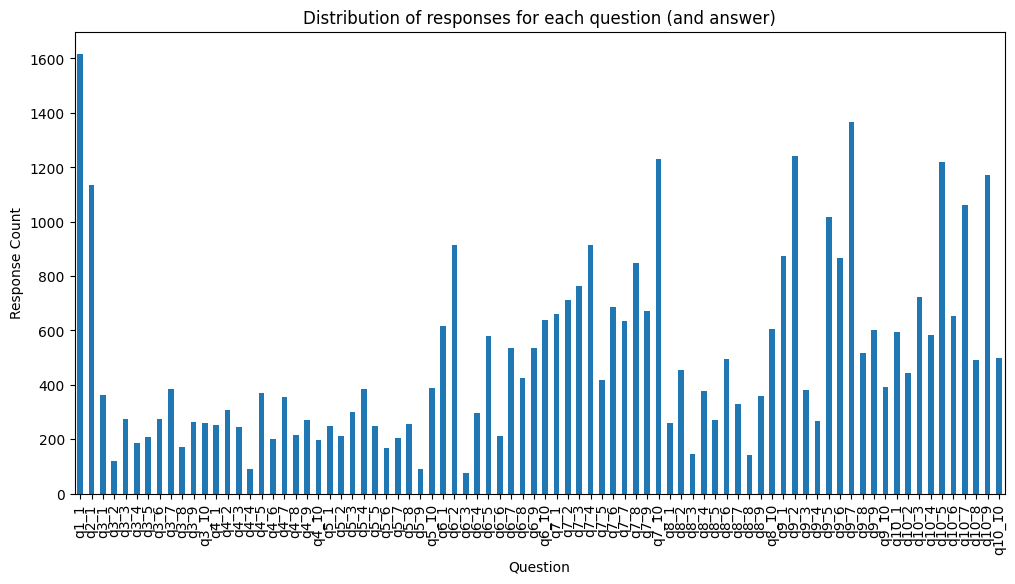

In [5]:
distribution = pdf.sum()

plt.figure(figsize=(12, 6))

distribution.plot(kind='bar')
plt.xlabel('Question')
plt.ylabel('Response Count')
plt.title('Distribution of responses for each question (and answer)')
plt.xticks(rotation=90)
plt.show()

**Analyse those questions that have sometimes been skipped**

We attempt to identify a pattern. Have they been skipped because the result is captured beforehand?

In [ ]:
non_null_q6 = pdf.dropna(subset=q6_cols)
non_null_q8 = pdf.dropna(subset=q8_cols)

print("Shape of `pdf` DataFrame after dropping rows where all q6 were NULL:", non_null_q6.shape)
print("Shape of `pdf` DataFrame after dropping rows where all q8 were NULL:", non_null_q8.shape)

In fact, there is a pattern. Q6 is only answered when Q1 is True. Q8 is only answered when Q2 is True. This could mean that Q6 is a continuation of the Q1 TRUE/FALSE question and Q8 is a continuation of the Q2 TRUE/FALSE question.

In [ ]:
response_distribution_q6 = non_null_q6.apply(pd.Series.value_counts).fillna(0)
response_distribution_q8 = non_null_q8.apply(pd.Series.value_counts).fillna(0)

display(response_distribution_q6.sort_values(by=1.0, axis=1, ascending=False))
display(response_distribution_q8.sort_values(by=1.0, axis=1, ascending=False))

**What should be done with Q6 & Q8 since we have NULL values inside of them?**

Two possible approaches:

1. Treat NULLs as 0. Since the dataset uses 1.0 to indicate a selected option, a missing response could reasonably be interpreted as the respondent not selecting any option for that question. This preserves all respondents in the training data and is the simplest approach. The risk is that "didn't answer" and "answered but selected nothing" may not be equivalent.
2. Drop the q6 and q8 columns entirely. Being that Q6 and Q8 are related to Q1 and Q2 respectively, it might be assumed that Q1 and Q2 contain enough information to represent the data in Q6 and Q8 and so they carry limited signal and may introduce noise.

Let's try both implementations and experiment with using a **Decision Tree Classifier**. We use a decision tree classifier for it's simplicity to both linear and non-linear relationships and also to be able to easily interpret the results due to the model's interpretability.

**Split into test/train**

We create the data as described in the two scenarios above and also split it into a test/train set with 70% for training and 30% for testing.

We also collapse the 10 binary q5 columns into one integer (1-10) by finding which column has the value 1. This will be used as our target variable.

In [ ]:
scenario_one_explanatory = explanatory.fillna(0)
scenario_two_explanatory = explanatory.drop(columns=q6_cols + q8_cols)
y = response.idxmax(axis=1).str.extract(r"q5_(\d+)").astype(int).squeeze()

print("Scenario one features (shape):", scenario_one_explanatory.shape)
print("Scenario two features (shape):", scenario_two_explanatory.shape)

print("\nY Classes:")
display(y)


scenario_one_X_train, scenario_one_X_test, scenario_one_y_train, scenario_one_y_test = train_test_split(scenario_one_explanatory, y, test_size=0.3, random_state=42, stratify=response)
scenario_two_X_train, scenario_two_X_test, scenario_two_y_train, scenario_two_y_test = train_test_split(scenario_two_explanatory, y, test_size=0.3, random_state=42, stratify=response)

print("\nScenario 1 (treat NaNs as 0):")
print("X (Training):", scenario_one_X_train.shape)
print("X (Testing):", scenario_one_X_test.shape)
print("y (Training):", scenario_one_y_test.shape)
print("y (Testing):", scenario_one_y_test.shape)

print("\nScenario 2 (drop Q6 and Q8):")
print("X (Training):", scenario_two_X_train.shape)
print("X (Testing):", scenario_two_X_test.shape)
print("y (Training):", scenario_two_y_test.shape)
print("y (Testing):", scenario_two_y_test.shape)

**Prepare grid search**

We prepare a grid search to be able to test the decision tree classifier with different hyperparameters. Since we have somewhat of a class imbalance, we use the f1 marco as the scoring as this assumes that all 10 options are equally important.

In [ ]:
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator = dt,
    param_grid = param_grid,
    cv = 5,
    scoring = "f1_macro",
    n_jobs = -1,
    verbose = 1,
)

**Evaluate grid search**

Using grid search to find the best hyperparameters for the Decision Tree model on the two different scenarios described above.

For each scenario, once we identify the best hyperparameters, we train a decision tree model using the best hyperparameters and evaluate it using the metrics we proposed in **Task 2**.

In [ ]:
grid_search.fit(scenario_one_X_train, scenario_one_y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-val Macro F1: {grid_search.best_score_:.4f}")

# fit the model using the best hyperparameters discovered during grid search
scenario_one_model = DecisionTreeClassifier(**grid_search.best_params_)
scenario_one_model.fit(scenario_one_X_train, scenario_one_y_train)
scenario_one_y_pred = scenario_one_model.predict(scenario_one_X_test)

acc = accuracy_score(scenario_one_y_test, scenario_one_y_pred)
f1_macro = f1_score(scenario_one_y_test, scenario_one_y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(scenario_one_y_test, scenario_one_y_pred, average="weighted", zero_division=0)
f1_micro = f1_score(scenario_one_y_test, scenario_one_y_pred, average="micro", zero_division=0)

print(f"\nAccuracy: {acc:.4f}")
print(f"Macro F1: {f1_macro:.4f} (all classes equally important)")
print(f"Weighted F1: {f1_weighted:.4f} (weighted by class frequency)")
print(f"Micro F1: {f1_micro:.4f} (aggregate TP/FP/FN across classes)")

In [ ]:
grid_search.fit(scenario_two_X_train, scenario_two_y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-val Macro F1: {grid_search.best_score_:.4f}")

# fit the model using the best hyperparameters discovered during grid search
scenario_two_model = DecisionTreeClassifier(**grid_search.best_params_)
scenario_two_model.fit(scenario_two_X_train, scenario_two_y_train)
scenario_two_y_pred = scenario_two_model.predict(scenario_two_X_test)

acc = accuracy_score(scenario_two_y_test, scenario_two_y_pred)
f1_macro = f1_score(scenario_two_y_test, scenario_two_y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(scenario_two_y_test, scenario_two_y_pred, average="weighted", zero_division=0)
f1_micro = f1_score(scenario_two_y_test, scenario_two_y_pred, average="micro", zero_division=0)

print(f"\nAccuracy: {acc:.4f}")
print(f"Macro F1: {f1_macro:.4f} (all classes equally important)")
print(f"Weighted F1: {f1_weighted:.4f} (weighted by class frequency)")
print(f"Micro F1: {f1_micro:.4f} (aggregate TP/FP/FN across classes)")

**Results**

As can be seen in both scenarios, the low F1 score suggests that the remaining survey questions provide limited predictive signal for Q5.

Moreover, including/excluding questions 6 and 8 does not really make a substantinal difference in the prediction either. However, for the next question we will use the model obtained under the assumptions of scenario one (treating NaNs as 0).

#### 3.1.3

Due to its transparent nature, interpreting the decision tree is possible and we can do so by visualising it.

*We visualise it with a depth of 3 to keep it visibile in the screen*.

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    scenario_one_model,
    feature_names=scenario_one_explanatory.columns.tolist(),
    class_names=[str(i) for i in range(1, 11)],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    f"Best Decision Tree (max_depth=7, criterion='gini'",
    fontsize=13,
)
plt.tight_layout()
plt.show()

**Structure**:

The tree flows top to bottom. Each node asks a yes/no question about a single feature, and the data is split accordingly. Respondents satisfying the condition go left, those that don't go right.

**Each node contains**

- **The split condition** (e.g. q3_2 <= 0.5): the feature and threshold the tree is splitting on. Since our features are binary (0 or 1), this effectively means "did the respondent select this option?"
- **Gini/Entropy**: the impurity of that node. 0 means perfectly pure (all one class), higher means more mixed.
- **Samples**: how many training respondents reached this node.
- **Values**: the class breakdown of those samples across all 10 q5 options.
- **Class**: the majority class at this node, i.e. what the tree would predict here.

**Leaf Nodes**:

The nodes at the bottom with no further splits are leaf nodes and these represent the final predictions. The predicted class is whichever value is largest in the values list at that node.

**Feature Importance**

Decision Trees also allow us to display the importance of each feature.

As can be seen, questions 2 and 1 were the most important explanatory features.

In [ ]:
importances = pd.Series(scenario_one_model.feature_importances_, index=scenario_one_explanatory.columns)
importances_sorted = importances[importances > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances_sorted.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Decision Tree — Feature Importances", fontsize=13)
ax.set_ylabel("Importance Score (Gini Impurity Reduction)")
ax.set_xlabel("Question (feature)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

#### 3.2.1

Assuming that question 5 is ordinal, we can use a **Decision Tree Regression Model** to handle the ordinal nature of the target variables.

In ordinal problems, we can no longer use evaluation metrics that were used for the classification. This is because evaluation metrics used in classification problems do not consider the order, when in ordinal problems, the order is very important. For example, predicting a 1 when the expected answer was a 10 is much worse than predicting a 9. 

In [ ]:
X_train = scenario_one_X_train 
X_test = scenario_one_X_test
y_train = scenario_one_y_train
y_test = scenario_one_y_test

dt_reg = DecisionTreeRegressor(random_state=42)

param_grid_reg = {
    "max_depth"        : [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf" : [1, 2, 5, 10],
}

grid_search_reg = GridSearchCV(
    estimator = dt_reg,
    param_grid = param_grid_reg,
    cv = 5,
    scoring = "neg_mean_absolute_error",
    n_jobs = -1,
)

grid_search_reg.fit(X_train, y_train)
best_dt_reg = grid_search_reg.best_estimator_

y_pred_reg = best_dt_reg.predict(X_test)
y_pred_rounded = y_pred_reg.round().clip(1, 10).astype(int)

print("Best parameters:", grid_search_reg.best_params_)

#### 3.2.2

Evaluate decision tree regression model built to predict Q5 in the case that order is important.

We will use two metrics:

- **Mean Absolute Error (MAE)**: Measures the average absolute difference between the predicted class and the true class. Unlike standard classification metrics, it respects the ordinal structure of q5. A prediction that is one step away from the truth incurs less penalty than one that is five steps away.
- **Spearman Correlation**: Measures the rank-order agreement between the predicted and actual values, ranging from -1 (perfect inverse ranking) to +1 (perfect ranking agreement). It assesses whether the model correctly orders respondents relative to each other, regardless of the exact predicted value.

**Final results**:

The MAE of 2.48 and Spearman correlation of 0.20, suggest that the remaining survey questions provide only weak predictive signal for the ordinal ranking of q5. This is consistent with the results obtained in the multi-classification part above.

In [ ]:
mae = mean_absolute_error(y_test, y_pred_rounded)
print(f"Mean Absolute Error: {mae:.4f}")

# spearman Correlation — measures rank-order agreement between predicted and actual
spearman_corr, p_value = spearmanr(y_test, y_pred_rounded)
print(f"Spearman Correlation: {spearman_corr:.4f} (p={p_value:.4f})")

## Task 4

### Code/Answers

#### 4.1.1

## (Informal) References:

- [Jaccard Similarity Made Simple: A Beginner’s Guide to Data Comparison](https://mayurdhvajsinhjadeja.medium.com/jaccard-similarity-34e2c15fb524)
- [What is Jaccard similarity? | IBM](https://www.ibm.com/think/topics/jaccard-similarity)
- [What is a decision tree? | IBM](https://www.ibm.com/think/topics/decision-trees)
- [Spearman's Rank-Order Correlation](https://statistics.laerd.com/statistical-guides/spearmans-rank-order-correlation-statistical-guide.php)